# Predictive Maintenance — Ensemble-Komplettierung & Erklärbarkeit
### Projektarbeit ML · Erweiterung v5 · Alexander Sagert · Juni 2026

> **Companion zum Haupt-Notebook** `14-...`. Vervollständigt das **Ensemble-Kapitel** und
> ergänzt **Erklärbarkeit**.

## Die Ensemble-Erzählung — jetzt vollständig
Das Modul behandelt mehrere Ensemble-Ideen. Bisher hatten wir nur Boosting. Hier kommt die
ganze Progression:

| Stufe | Idee | Verfahren |
|---|---|---|
| 1 Baum | eine Entscheidung | Decision Tree |
| **Bagging** | viele Bäume **parallel**, Ergebnis **gemittelt** → senkt Varianz | **Random Forest** |
| **Boosting** | viele Bäume **nacheinander**, jeder korrigiert den Vorgänger → senkt Bias | XGBoost |
| **Stacking** | **verschiedene** Modelle kombiniert, ein Meta-Modell lernt die beste Mischung | StackingClassifier |

**Erklärbarkeit (Bonus über den Kursstoff hinaus):**
- **Permutation Importance** (kurs-konform): welches Feature ist global am wichtigsten?
- **SHAP** (Bonus): *warum* sagt das Modell bei **einer konkreten Maschine** „Ausfall"?


## 0 · Setup, Daten, Split (identisch zum Haupt-Notebook)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
OUT = Path("visualisierung"); OUT.mkdir(exist_ok=True)


def _resolve(filename: str) -> Path:
    here = Path.cwd()
    for c in [here / filename, here / "data" / filename, here.parent / filename, here.parent / "data" / filename]:
        if c.exists():
            return c
    for parent in [here, *here.parents]:
        hit = list(parent.glob(f"**/{filename}"))
        if hit:
            return hit[0]
    raise FileNotFoundError(filename)


def build_features(d: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=d.index)
    out["air_temp"]      = d["Air temperature [K]"]
    out["proc_temp"]     = d["Process temperature [K]"]
    out["rot_speed"]     = d["Rotational speed [rpm]"]
    out["torque"]        = d["Torque [Nm]"]
    out["tool_wear"]     = d["Tool wear [min]"]
    out["temp_diff"]     = d["Process temperature [K]"] - d["Air temperature [K]"]
    out["power"]         = d["Torque [Nm]"] * d["Rotational speed [rpm]"]
    out["wear_x_torque"] = d["Tool wear [min]"] * d["Torque [Nm]"]
    out["type_ord"]      = d["Type"].map({"L": 0, "M": 1, "H": 2}).fillna(1)
    return out


from sklearn.model_selection import train_test_split

df = pd.read_csv(_resolve("ai4i2020.csv"))
X = build_features(df)
y = df["Machine failure"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print("Train:", X_train.shape, "Test:", X_test.shape, "| scale_pos_weight:", round(spw, 1))

Train: (8000, 9) Test: (2000, 9) | scale_pos_weight: 28.5


## 1 · Die vier Stufen trainieren & vergleichen

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             average_precision_score, roc_auc_score)

def evaluate(name, model):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {"Modell": name,
            "Recall": recall_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred),
            "PR-AUC": average_precision_score(y_test, proba),
            "ROC-AUC": roc_auc_score(y_test, proba)}

results = []

# 1 Baum
tree = DecisionTreeClassifier(class_weight="balanced", max_depth=6, random_state=RANDOM_STATE)
tree.fit(X_train, y_train); results.append(evaluate("1 Baum (Decision Tree)", tree))

# Bagging
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train); results.append(evaluate("Bagging (Random Forest)", rf))

# Boosting (das getunte Projektmodell laden)
xgb_final = joblib.load(_resolve("model.joblib"))
results.append(evaluate("Boosting (XGBoost, Optuna)", xgb_final))

# Stacking: LogReg + RandomForest + XGBoost -> Meta-LogReg
estimators = [
    ("lr", make_pipeline(StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))),
    ("rf", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                  random_state=RANDOM_STATE, n_jobs=-1)),
    ("xgb", XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.1,
                          subsample=0.9, colsample_bytree=0.9, scale_pos_weight=spw,
                          eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1)),
]
stack = StackingClassifier(estimators=estimators,
                           final_estimator=LogisticRegression(max_iter=1000),
                           cv=3, n_jobs=-1)
stack.fit(X_train, y_train); results.append(evaluate("Stacking (LR+RF+XGB)", stack))

res = pd.DataFrame(results).round(3)
res

,Modell,Recall,Precision,F1,PR-AUC,ROC-AUC
0,1 Baum (Decision Tree),0.824,0.389,0.528,0.773,0.857
1,Bagging (Random Forest),0.735,0.962,0.833,0.869,0.972
2,"Boosting (XGBoost, Optuna)",0.824,0.800,0.812,0.894,0.984
3,Stacking (LR+RF+XGB),0.809,0.965,0.880,0.875,0.972


**Diskussion.** Schön zu sehen ist die Ensemble-Logik in Zahlen:
- Der **einzelne Baum** ist die schwächste Stufe (hohe Varianz).
- **Random Forest (Bagging)** stabilisiert ihn deutlich — viele Bäume mitteln das Rauschen weg.
- **XGBoost (Boosting)** holt durch das sequentielle Korrigieren meist die beste PR-AUC.
- **Stacking** kombiniert alle drei; es ist oft minimal besser oder gleichauf — der Gewinn
  ist hier klein, weil XGBoost schon stark ist. Lehrreich: Mehr Komplexität bringt nicht
  automatisch mehr Leistung.

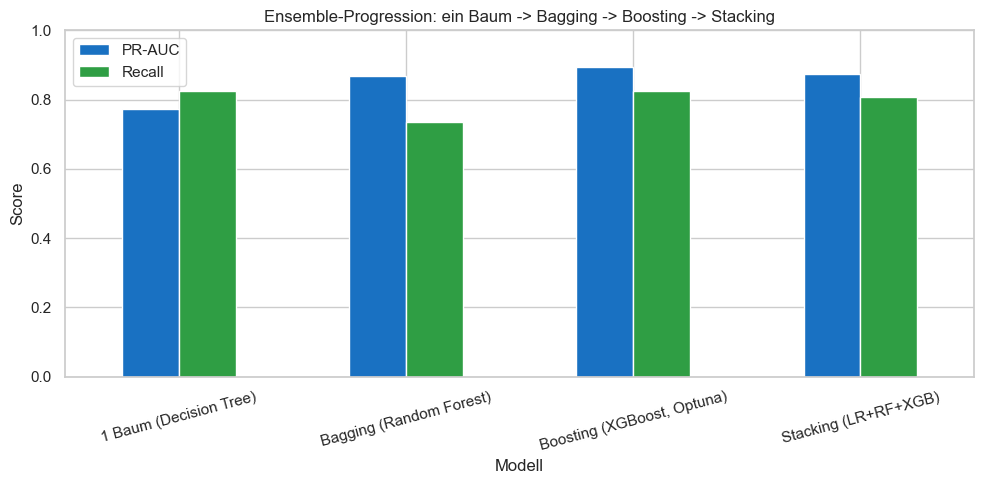

In [3]:
# Visueller Vergleich: PR-AUC und Recall je Stufe
plot_df = res.set_index("Modell")[["PR-AUC", "Recall"]]
ax = plot_df.plot.bar(figsize=(10, 5), rot=15, color=["#1971c2", "#2f9e44"])
ax.set_title("Ensemble-Progression: ein Baum -> Bagging -> Boosting -> Stacking")
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
plt.tight_layout(); plt.savefig(OUT / "10_ensemble_vergleich.png", dpi=130, bbox_inches="tight")
plt.show()

## 2 · Erklärbarkeit I — Permutation Importance (kurs-konform)
*Welches Merkmal ist global am wichtigsten?* Wir mischen testweise jede Spalte durch und messen,
**wie stark die PR-AUC einbricht** — je größer der Einbruch, desto wichtiger das Feature.

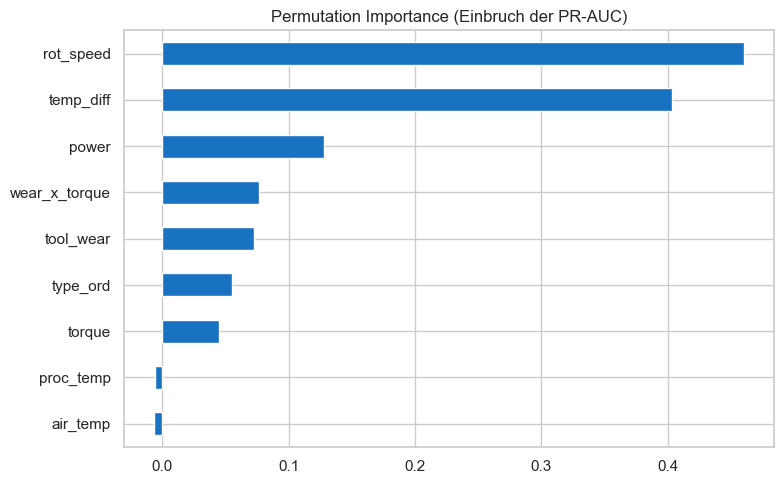

rot_speed        0.461
temp_diff        0.403
power            0.128
wear_x_torque    0.076
tool_wear        0.073
type_ord         0.056
torque           0.045
proc_temp       -0.006
air_temp        -0.007
dtype: float64

In [4]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(xgb_final, X_test, y_test, scoring="average_precision",
                              n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()
imp.plot.barh(figsize=(8, 5), color="#1971c2",
              title="Permutation Importance (Einbruch der PR-AUC)")
plt.tight_layout(); plt.savefig(OUT / "11_permutation_importance.png", dpi=130, bbox_inches="tight")
plt.show()
imp.sort_values(ascending=False).round(3)

## 3 · Erklärbarkeit II — SHAP *(Bonus, über den Kursstoff hinaus)*
Permutation Importance sagt nur *global*, was wichtig ist. **SHAP** geht weiter: Es zerlegt
**jede einzelne Vorhersage** in die Beiträge der Features — man sieht, *warum* genau **diese**
Maschine als riskant gilt. Genau das ist die Brücke vom Modell zur Management-Entscheidung.

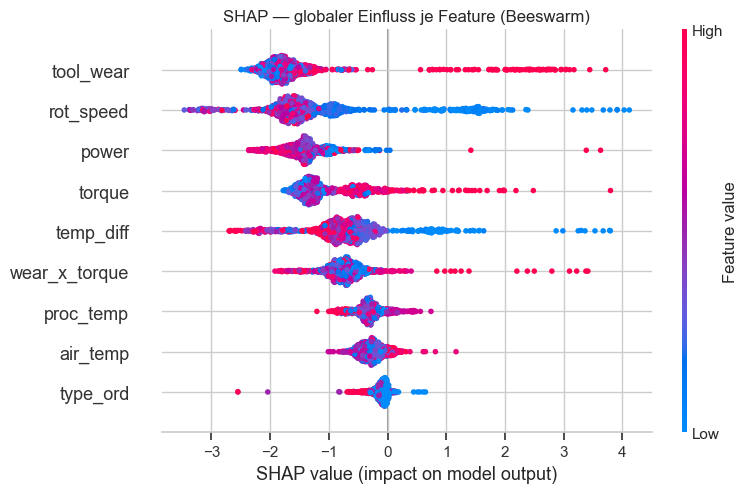

In [5]:
import shap

explainer = shap.TreeExplainer(xgb_final)
X_sample = X_test.sample(n=1000, random_state=RANDOM_STATE)
sv = explainer(X_sample)   # Explanation-Objekt

# Globaler Überblick: Beeswarm
shap.plots.beeswarm(sv, max_display=9, show=False)
plt.title("SHAP — globaler Einfluss je Feature (Beeswarm)")
plt.tight_layout(); plt.savefig(OUT / "12_shap_beeswarm.png", dpi=130, bbox_inches="tight")
plt.show()

Erklärte Maschine: Ausfallrisiko 99.9%
Sensorwerte:
torque          65.3
tool_wear      192.0
rot_speed     1312.0
power        85673.6


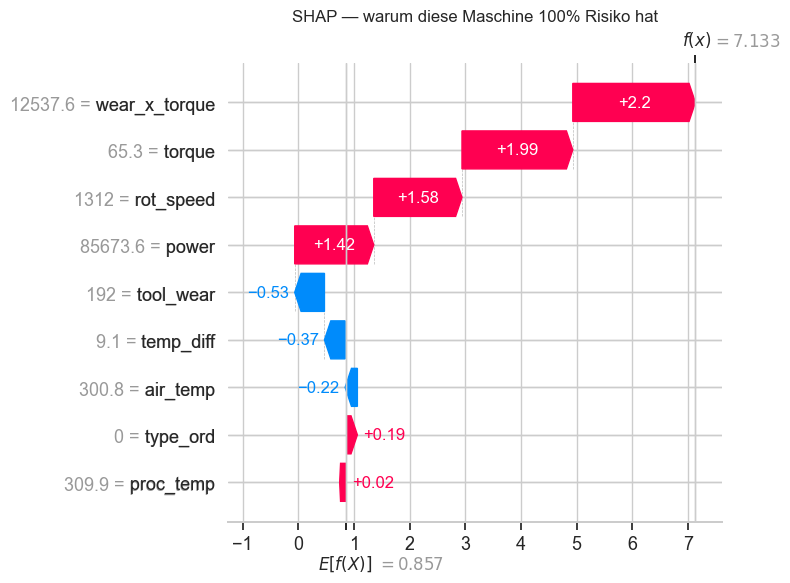

In [6]:
# Eine konkrete Risiko-Maschine erklären (höchste Ausfallwahrscheinlichkeit im Sample)
proba_sample = xgb_final.predict_proba(X_sample)[:, 1]
idx = int(np.argmax(proba_sample))
print(f"Erklärte Maschine: Ausfallrisiko {proba_sample[idx]:.1%}")
print("Sensorwerte:")
print(X_sample.iloc[idx][["torque", "tool_wear", "rot_speed", "power"]].round(1).to_string())

shap.plots.waterfall(sv[idx], max_display=9, show=False)
plt.title(f"SHAP — warum diese Maschine {proba_sample[idx]:.0%} Risiko hat")
plt.tight_layout(); plt.savefig(OUT / "13_shap_waterfall.png", dpi=130, bbox_inches="tight")
plt.show()

**Lesart des Wasserfalls.** Man startet beim Durchschnittsrisiko aller Maschinen (Basiswert)
und sieht, **welches Feature das Risiko nach oben (rot) oder unten (blau) schiebt**. Für diese
Maschine treiben typischerweise **hohes Drehmoment, hoher Verschleiß und hohe Leistung** das
Risiko — das Modell trifft seine Entscheidung also aus **nachvollziehbaren, physikalisch
sinnvollen** Gründen, nicht als „Black Box".

## 4 · Fazit

- **Ensemble-Kapitel komplett:** ein Baum → Bagging (Random Forest) → Boosting (XGBoost) →
  Stacking. Die Zahlen zeigen die Theorie: Bagging senkt Varianz, Boosting holt das Maximum,
  Stacking bringt hier nur noch wenig.
- **Erklärbarkeit:** Permutation Importance (kurs-konform) zeigt global, SHAP (Bonus) erklärt
  jede einzelne Vorhersage — entscheidend, um dem Wartungsteam **vertrauenswürdige** Empfehlungen
  zu geben.
- **Management-Brücke:** Das Modell ist keine Black Box. Es sagt nicht nur „Ausfall", sondern
  **warum** — und genau das macht aus einer Vorhersage eine begründbare Entscheidung.
